Demo - 2

Visualize data

In [146]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import mean_squared_error, r2_score

from tqdm.keras import TqdmCallback
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.utils import to_categorical

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Training the *model*

In [147]:
# Load the dataset
url = 'http://users.jyu.fi/~olkhriye/ties4911/demos/demo1/Automobile_price_data_Raw_set.csv'
df = pd.read_csv(url)

# Select relevant columns
columns = ['make', 'body-style', 'wheel-base', 'engine-size', 'horsepower', 'peak-rpm', 'highway-mpg', 'price']
df = df[columns]

df

,make,body-style,wheel-base,engine-size,horsepower,peak-rpm,highway-mpg,price
0,alfa-romero,convertible,88.6,130,111.0,5000.0,27,13495.0
1,alfa-romero,convertible,88.6,130,111.0,5000.0,27,16500.0
2,alfa-romero,hatchback,94.5,152,154.0,5000.0,26,16500.0
3,audi,sedan,99.8,109,102.0,5500.0,30,13950.0
4,audi,sedan,99.4,136,115.0,5500.0,22,17450.0
...,...,...,...,...,...,...,...,...
200,volvo,sedan,109.1,141,114.0,5400.0,28,16845.0
201,volvo,sedan,109.1,141,160.0,5300.0,25,19045.0
202,volvo,sedan,109.1,173,134.0,5500.0,23,21485.0
203,volvo,sedan,109.1,145,106.0,4800.0,27,22470.0


<ipython-input-148-43c1a808f59c>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["make"], palette="viridis")


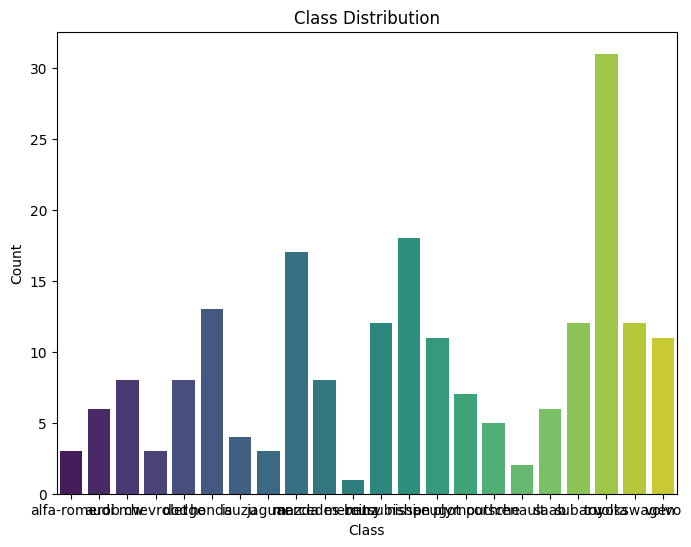

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=df["make"], palette="viridis")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

There is a one make type only have one record called "mercury". Gonna drop that record

In [149]:
# Get the list of makes with less than 2 records
less_than_2_records = df.groupby('make')['make'].count()[df.groupby('make')['make'].count() < 2].index.tolist()

# Filter the DataFrame to exclude these makes
filtered_df = df[~df['make'].isin(less_than_2_records)]
df = filtered_df
df

,make,body-style,wheel-base,engine-size,horsepower,peak-rpm,highway-mpg,price
0,alfa-romero,convertible,88.6,130,111.0,5000.0,27,13495.0
1,alfa-romero,convertible,88.6,130,111.0,5000.0,27,16500.0
2,alfa-romero,hatchback,94.5,152,154.0,5000.0,26,16500.0
3,audi,sedan,99.8,109,102.0,5500.0,30,13950.0
4,audi,sedan,99.4,136,115.0,5500.0,22,17450.0
...,...,...,...,...,...,...,...,...
200,volvo,sedan,109.1,141,114.0,5400.0,28,16845.0
201,volvo,sedan,109.1,141,160.0,5300.0,25,19045.0
202,volvo,sedan,109.1,173,134.0,5500.0,23,21485.0
203,volvo,sedan,109.1,145,106.0,4800.0,27,22470.0


In [150]:
# Handle missing values
df.dropna(inplace=True)

<ipython-input-150-7ac94ee1d893>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


In [151]:
# Encode categorical variables

# Create separate encoder objects for each categorical feature
encoder_body_style = OneHotEncoder(sparse_output=False)  # Encoder for body-style
encoder_make = OneHotEncoder(sparse_output=False)  # Encoder for make

encoded_body_style = encoder_body_style.fit_transform(df[['body-style']]) # Use specific encoder
encoded_make = encoder_make.fit_transform(df[['make']]) # Use specific encoder

# Create DataFrame for encoded features
encoded_body_style_df = pd.DataFrame(encoded_body_style, columns=encoder_body_style.get_feature_names_out(['body-style'])) # Use specific encoder
encoded_make_df = pd.DataFrame(encoded_make, columns=encoder_make.get_feature_names_out(['make'])) # Use specific encoder

# Concatenate encoded features with numerical features
numerical_features = df[['wheel-base', 'engine-size', 'horsepower', 'peak-rpm', 'highway-mpg', 'price']]
X = pd.concat([numerical_features.reset_index(drop=True), encoded_body_style_df.reset_index(drop=True)], axis=1)
y = encoded_make_df

# Normalize numerical features
scaler = StandardScaler()
X[numerical_features.columns] = scaler.fit_transform(numerical_features)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Training the model

In [154]:
y_train.shape[1]

20

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Accuracy: 0.4655
Test Loss: 2.9016


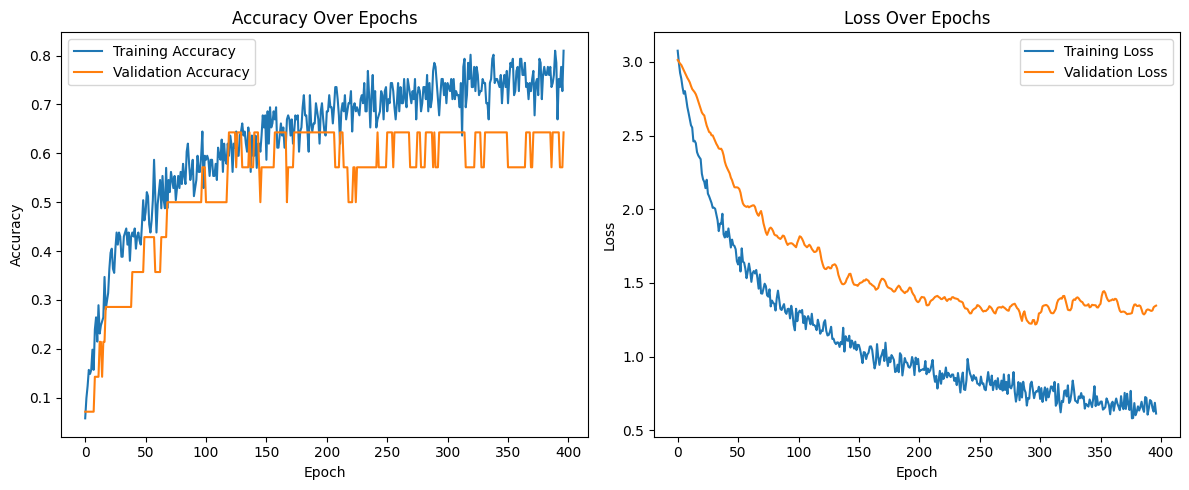

In [158]:
# Build the neural network model
# model = Sequential()
# model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
# model.add(Dense(64, activation='relu'))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(y_train.shape[1], activation='softmax'))

# Define the model
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(y_train.shape[1], activation="softmax")  # Output layer for multiclass classification
])

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Early stopping callback
early_stopping = EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-4)

# Train the model
history = model.fit(X_train, y_train, epochs=1000, batch_size=20, validation_split=0.1,
                    callbacks=[early_stopping, TqdmCallback(verbose=1)], verbose=0)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Prediction

In [159]:
# Example predictions
import numpy as np

# Function to preprocess input data
def preprocess_input(input_data):
    input_df = pd.DataFrame([input_data], columns=['body-style', 'wheel-base', 'engine-size', 'horsepower', 'peak-rpm', 'highway-mpg', 'price'])

    # Encode 'body-style' and create a temporary DataFrame
    encoded_body_style_input = encoder_body_style.transform(input_df[['body-style']])
    encoded_body_style_df = pd.DataFrame(encoded_body_style_input, columns=encoder_body_style.get_feature_names_out(['body-style']))

    # Drop the original 'body-style' column and concatenate the encoded features
    input_df = input_df.drop('body-style', axis=1)
    input_df = pd.concat([input_df.reset_index(drop=True), encoded_body_style_df.reset_index(drop=True)], axis=1)

    # Scale numerical features
    input_df[numerical_features.columns] = scaler.transform(input_df[numerical_features.columns])

    return input_df

In [160]:
# Input data
input_1 = ['sedan', 103.5, 164, 121, 4250, 25, 24565]
input_2 = ['hatchback', 86.6, 92, 58, 4800, 54, 6479]

# Preprocess inputs
processed_input_1 = preprocess_input(input_1)
processed_input_2 = preprocess_input(input_2)

# Predict
prediction_1 = model.predict(processed_input_1)
prediction_2 = model.predict(processed_input_2)

# Decode predictions
predicted_make_1 = encoder_make.inverse_transform(prediction_1) # Use specific encoder
predicted_make_2 = encoder_make.inverse_transform(prediction_2) # Use specific encoder

print(f"Predicted make for input 1: {predicted_make_1[0]}")
print(f"Predicted make for input 2: {predicted_make_2[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted make for input 1: ['bmw']
Predicted make for input 2: ['chevrolet']
